In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score



In [5]:
train = pd.read_csv('Datasets/HousePrice/train.csv')

In [6]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
train.shape

(1460, 81)

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
train.isnull().sum()


Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [10]:
none_cols = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

train[none_cols] = train[none_cols].fillna('None')


In [11]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


In [12]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
Alley              0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
HouseStyle         0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
Exterior1st        0
Exterior2nd        0
MasVnrType         0
MasVnrArea         8
ExterQual          0
ExterCond          0
Foundation         0
BsmtQual           0
BsmtCond           0
BsmtExposure       0
BsmtFinType1       0
BsmtFinSF1         0
BsmtFinType2       0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
Heating            0
HeatingQC          0
CentralAir         0
Electrical         1
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath 

In [13]:
# LotFrontage: numeric, correlates with neighborhood, so fill with the neighborhood's median instead of a global median
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# MasVnrArea: NaN here lines up with MasVnrType='None' (no veneer) -> 0 makes sense
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

# Electrical: only 1 missing, categorical -> fill with the mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# GarageYrBlt: NaN means no garage. Filling with 0 would create a fake "year 0" that distorts scale/correlations,
# so fill with YearBuilt instead (common convention: assume garage as old as the house if it existed)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])


In [14]:
train.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

In [15]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    train[col] = train[col].map(qual_map)


In [18]:
train[['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']].apply(pd.Series.unique)

ExterQual            [4, 3, 5, 2]
ExterCond         [3, 4, 2, 1, 5]
BsmtQual          [4, 3, 5, 0, 2]
BsmtCond          [3, 4, 0, 2, 1]
HeatingQC         [5, 4, 3, 2, 1]
KitchenQual          [4, 3, 5, 2]
FireplaceQu    [0, 3, 4, 2, 5, 1]
GarageQual     [3, 2, 4, 0, 5, 1]
GarageCond     [3, 2, 0, 4, 1, 5]
PoolQC               [0, 5, 2, 4]
dtype: object

In [19]:
train['BsmtExposure'] = train['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})

fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
train['BsmtFinType1'] = train['BsmtFinType1'].map(fin_map)
train['BsmtFinType2'] = train['BsmtFinType2'].map(fin_map)

train['GarageFinish'] = train['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})
train['LandSlope'] = train['LandSlope'].map({'Gtl': 3, 'Mod': 2, 'Sev': 1})
train['LotShape'] = train['LotShape'].map({'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1})
train['CentralAir'] = train['CentralAir'].map({'Y': 1, 'N': 0})


In [20]:
train.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'Foundation', 'Heating', 'Electrical', 'Functional', 'GarageType',
       'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')

In [21]:
train['Functional'] = train['Functional'].map({'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5,
                                                  'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1})

train['PavedDrive'] = train['PavedDrive'].map({'Y': 2, 'P': 1, 'N': 0})

train['Fence'] = train['Fence'].map({'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0})


In [22]:
train['Utilities'].value_counts()


Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [23]:
train = train.drop(columns=['Utilities'])


In [24]:
nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
                 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature',
                 'SaleType', 'SaleCondition']

train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)


In [25]:
train.head()

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,4,3,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,1,856,854,0,1710,1,0,2,1,3,1,4,8,8,0,0,2003.0,2,2,548,3,3,2,0,61,0,0,0,0,0,0,0,2,2008,208500,False,False,True,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False,Fal

In [26]:
train.shape

(1460, 203)

In [27]:
# Total living space across floors + basement — often more predictive alone than the 3 separate columns
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']

# Age of house and of the remodel at time of sale, instead of raw year values
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
train['GarageAge'] = train['YrSold'] - train['GarageYrBlt']

# Total bathrooms as one combined count (half baths count as 0.5)
train['TotalBath'] = (train['FullBath'] + 0.5 * train['HalfBath'] +
                       train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath'])


In [28]:
train.shape

(1460, 208)

In [29]:
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr


SalePrice                1.000000
OverallQual              0.790982
TotalSF                  0.782260
GrLivArea                0.708624
ExterQual                0.682639
KitchenQual              0.659600
GarageCars               0.640409
TotalBath                0.631731
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
BsmtQual                 0.585207
FullBath                 0.560664
GarageFinish             0.549247
TotRmsAbvGrd             0.533723
YearBuilt                0.522897
FireplaceQu              0.520438
GarageYrBlt              0.508043
YearRemodAdd             0.507101
Foundation_PConc         0.497734
MasVnrArea               0.472614
Fireplaces               0.466929
HeatingQC                0.427649
Neighborhood_NridgHt     0.402149
BsmtFinSF1               0.386420
BsmtExposure             0.374696
SaleType_New             0.357509
SaleCondition_Partial    0.352060
LotFrontage              0.349876
GarageType_Att

In [ ]:
check_cols = ['TotalSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
              'GarageCars', 'GarageArea', 'TotalBath', 'FullBath',
              'YearBuilt', 'HouseAge', 'OverallQual', 'GrLivArea']

train[check_cols].corr()


In [31]:
check_cols = ['TotalSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
              'GarageCars', 'GarageArea', 'TotalBath', 'FullBath',
              'YearBuilt', 'HouseAge', 'OverallQual', 'GrLivArea']

train[check_cols].corr()


,TotalSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageCars,GarageArea,TotalBath,FullBath,YearBuilt,HouseAge,OverallQual,GrLivArea
TotalSF,1.000000,0.826742,0.800350,0.342733,0.536413,0.563747,0.604324,0.575762,0.347133,-0.347892,0.668155,0.874373
TotalBsmtSF,0.826742,1.000000,0.819530,-0.174512,0.434585,0.486665,0.414468,0.323722,0.391452,-0.391498,0.537808,0.454868
1stFlrSF,0.800350,0.819530,1.000000,-0.202646,0.439317,0.489782,0.390557,0.380637,0.281986,-0.282143,0.476224,0.566024
2ndFlrSF,0.342733,-0.174512,-0.202646,1.000000,0.183926,0.138347,0.375160,0.421378,0.010308,-0.011552,0.295493,0.687501
GarageCars,0.536413,0.434585,0.439317,0.183926,1.000000,0.882475,0.483578,0.469672,0.537850,-0.538727,0.600671,0.467247
GarageArea,0.563747,0.486665,0.489782,0.138347,0.882475,1.000000,0.451567,0.405656,0.478954,-0.479408,0.562022,0.468997
TotalBath,0.604324,0.414468,0.390557,0.375160,0.483578,0.451567,1.000000,0.694197,0.524298,-0.522595,0.541063,0.595169
FullBath,0.575762,0.323722,0.380637,0.421378,0.469672,0.405656,0.694197,1.000000,0.468271,-0.468403,0.550600,0.630012
YearBuilt,0.347133,0.391452,0.281986,0.010308,0.537850,0.478954,0.524298,0.468271,1.000000,-0.999036,0.572323,0.199010
HouseAge,-0.347892,-0.391498,-0.282143,-0.011552,-0.538727,-0.479408,-0.522595,-0.468403,-0.999036,1.000000,-0.572629,-0.200302


In [32]:
train = train.drop(columns=['YearBuilt', 'GarageArea'])


In [33]:
train.shape

(1460, 206)

In [34]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X = train.drop(columns=['SalePrice', 'Id'])
y = train['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

coef = pd.Series(lasso.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coef


GrLivArea                24099.902104
OverallQual              14751.402103
Neighborhood_NridgHt      9566.994998
MSSubClass               -8653.151885
GarageCars                6780.634968
Neighborhood_NoRidge      6685.485371
BsmtExposure              6479.337222
Neighborhood_StoneBr      5646.848750
RoofMatl_WdShngl          5610.580373
KitchenQual               5346.970362
Condition2_PosN          -5218.407755
TotalBath                 4992.588618
SaleType_New              4585.671966
ExterQual                 4208.761833
OverallCond               3549.538086
MasVnrArea                3543.995164
BsmtQual                  3306.778977
Neighborhood_Crawfor      3016.909489
BsmtFinSF1                2678.531881
LotArea                   2659.065894
HouseAge                 -2472.008557
Fireplaces                2462.211286
LotConfig_CulDSac         2333.247620
RoofStyle_Gable          -2322.257729
BsmtFinType1              2282.127661
Condition1_Norm           2199.648387
Exterior1st_

In [35]:
nonzero = coef[coef != 0]
print(f"Kept: {len(nonzero)} / {len(coef)} features")
nonzero


Kept: 75 / 204 features


GrLivArea               24099.902104
OverallQual             14751.402103
Neighborhood_NridgHt     9566.994998
MSSubClass              -8653.151885
GarageCars               6780.634968
Neighborhood_NoRidge     6685.485371
BsmtExposure             6479.337222
Neighborhood_StoneBr     5646.848750
RoofMatl_WdShngl         5610.580373
KitchenQual              5346.970362
Condition2_PosN         -5218.407755
TotalBath                4992.588618
SaleType_New             4585.671966
ExterQual                4208.761833
OverallCond              3549.538086
MasVnrArea               3543.995164
BsmtQual                 3306.778977
Neighborhood_Crawfor     3016.909489
BsmtFinSF1               2678.531881
LotArea                  2659.065894
HouseAge                -2472.008557
Fireplaces               2462.211286
LotConfig_CulDSac        2333.247620
RoofStyle_Gable         -2322.257729
BsmtFinType1             2282.127661
Condition1_Norm          2199.648387
Exterior1st_BrkFace      2174.338265
N

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importances.head(25)


TotalSF         0.427661
OverallQual     0.338293
2ndFlrSF        0.028722
HouseAge        0.017875
BsmtFinSF1      0.011949
LotArea         0.010959
KitchenQual     0.010571
TotalBath       0.010475
GrLivArea       0.010311
GarageCars      0.009368
BsmtQual        0.009313
BsmtUnfSF       0.006611
LotFrontage     0.005857
YearRemodAdd    0.005852
OverallCond     0.005420
RemodAge        0.004988
GarageYrBlt     0.004703
TotalBsmtSF     0.004695
1stFlrSF        0.004262
OpenPorchSF     0.003897
MoSold          0.003841
MasVnrArea      0.003654
FireplaceQu     0.003345
TotRmsAbvGrd    0.003209
WoodDeckSF      0.003153
dtype: float64

In [37]:
len(rf_importances)

204

In [38]:

rf_selected = set(rf_importances[rf_importances > 0.001].index)
lasso_selected = set(nonzero.index)

final_features = rf_selected | lasso_selected

# Collapse the redundant size cluster to ONE representative instead of keeping all of them —
# TotalSF wins: it's the aggregate, has the highest single RF importance, and correlates 0.78 with SalePrice
size_cluster = {'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'BsmtUnfSF'}
final_features -= size_cluster

final_features = list(final_features)
print(f"Final feature count: {len(final_features)}")

X_final = train[final_features]
y_final = train['SalePrice']


Final feature count: 84


In [39]:
print(final_features)

['BsmtFinSF1', 'BedroomAbvGr', 'LotConfig_FR2', 'Condition2_PosN', 'BsmtFinType1', 'Neighborhood_OldTown', 'SaleType_New', 'BsmtCond', 'TotalSF', 'GarageYrBlt', 'GarageFinish', 'ScreenPorch', 'Foundation_PConc', 'KitchenQual', 'Condition1_Feedr', 'MSZoning_RL', 'GarageType_None', 'Heating_OthW', 'Exterior2nd_ImStucc', 'SaleType_Con', 'LotConfig_CulDSac', 'Neighborhood_NoRidge', 'SaleCondition_Family', 'MSZoning_RM', 'GarageAge', 'OverallCond', 'BldgType_2fmCon', 'GarageCars', 'YrSold', 'Condition2_PosA', 'Exterior1st_Wd Sdng', 'Exterior1st_CemntBd', 'MoSold', 'Exterior2nd_Wd Shng', 'KitchenAbvGr', 'CentralAir', 'BsmtQual', 'Neighborhood_Edwards', 'Neighborhood_Crawfor', 'Functional', 'LotFrontage', 'MasVnrArea', 'MasVnrType_BrkFace', 'WoodDeckSF', 'HouseAge', 'FireplaceQu', 'YearRemodAdd', 'Street_Pave', 'Neighborhood_NridgHt', 'BldgType_Twnhs', 'RoofMatl_WdShngl', 'RoofMatl_Membran', 'Neighborhood_StoneBr', 'TotRmsAbvGrd', 'RoofStyle_Gable', 'GarageType_BuiltIn', 'RemodAge', 'LotShape

In [40]:

X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Lasso needs scaled features
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_val_scaled = scaler_final.transform(X_val)

lasso_final = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)
lasso_preds = lasso_final.predict(X_val_scaled)

rf_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
rf_preds = rf_final.predict(X_val)

for name, preds in [('Lasso', lasso_preds), ('Random Forest', rf_preds)]:
    rmse = mean_squared_error(y_val, preds) ** 0.5
    r2 = r2_score(y_val, preds)
    print(f"{name}: RMSE = {rmse:,.0f}, R2 = {r2:.4f}")


Lasso: RMSE = 30,998, R2 = 0.8747
Random Forest: RMSE = 31,093, R2 = 0.8740


In [41]:
test = pd.read_csv('Datasets/HousePrice/test.csv')

In [42]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [43]:
train_raw = pd.read_csv('Datasets/HousePrice/train.csv')
test_raw = pd.read_csv('Datasets/HousePrice/test.csv')

# Stats computed from TRAIN only, reused for both train and test
stats = {
    'neighborhood_medians': train_raw.groupby('Neighborhood')['LotFrontage'].median(),
    'lotfrontage_median': train_raw['LotFrontage'].median(),
    'electrical_mode': train_raw['Electrical'].mode()[0],
    'modes': {col: train_raw[col].mode()[0] for col in
              ['MSZoning', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']}
}

def engineer_features(df, stats):
    df = df.copy()

    none_cols = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
                 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
    df[none_cols] = df[none_cols].fillna('None')

    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(stats['neighborhood_medians']))
    df['LotFrontage'] = df['LotFrontage'].fillna(stats['lotfrontage_median'])
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['Electrical'] = df['Electrical'].fillna(stats['electrical_mode'])
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # Kaggle's test.csv has a few extra missing columns train.csv didn't have.
    # Zero fill = "doesn't have this feature" (no basement/garage); mode fill = single stray missing values.
    for col in ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']:
        df[col] = df[col].fillna(0)
    for col in stats['modes']:
        df[col] = df[col].fillna(stats['modes'][col])

    df = df.drop(columns=['Utilities'])

    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
        df[col] = df[col].map(qual_map)

    df['BsmtExposure'] = df['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})
    fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
    df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map)
    df['BsmtFinType2'] = df['BsmtFinType2'].map(fin_map)
    df['GarageFinish'] = df['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})
    df['LandSlope'] = df['LandSlope'].map({'Gtl': 3, 'Mod': 2, 'Sev': 1})
    df['LotShape'] = df['LotShape'].map({'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1})
    df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})
    df['Functional'] = df['Functional'].map({'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5,
                                               'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1})
    df['PavedDrive'] = df['PavedDrive'].map({'Y': 2, 'P': 1, 'N': 0})
    df['Fence'] = df['Fence'].map({'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0})

    nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                     'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                     'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
                     'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature',
                     'SaleType', 'SaleCondition']
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                        df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

    return df.drop(columns=['YearBuilt', 'GarageArea'])

train_clean = engineer_features(train_raw, stats)
test_clean = engineer_features(test_raw, stats)


In [44]:
X_test_final = test_clean.reindex(columns=final_features, fill_value=0)



In [45]:
scaler_submit = StandardScaler()
X_final_scaled = scaler_submit.fit_transform(X_final)
X_test_scaled = scaler_submit.transform(X_test_final)

lasso_submit = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_final_scaled, y_final)
rf_submit = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_final, y_final)

lasso_test_preds = lasso_submit.predict(X_test_scaled)
rf_test_preds = rf_submit.predict(X_test_final)


In [46]:
print(X_test_final.isnull().sum().sum())   # should be 0 — any NaN here means a column slipped through unfilled
print(lasso_test_preds[:5])
print(rf_test_preds[:5])
pd.Series(lasso_test_preds).describe()


0
[ 77471.52451479 138502.89486004 142986.73998078 161509.74718349
 210027.92692576]
[121503.45666667 166106.32       184328.19333333 188041.57666667
 193292.13      ]


count      1459.000000
mean     156032.934664
std       75614.982027
min      -10572.843279
25%      104574.158040
50%      139409.123877
75%      193773.030640
max      560622.608677
dtype: float64

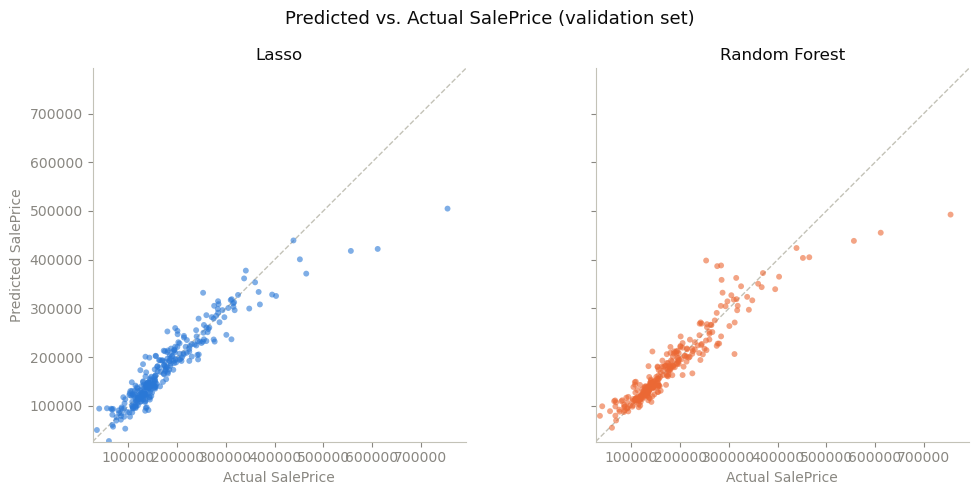

In [47]:
import matplotlib.pyplot as plt

BLUE = '#2a78d6'    # Lasso
ORANGE = '#eb6834'  # Random Forest
MUTED = '#898781'
BASELINE = '#c3c2b7'

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

lims = [min(y_val.min(), lasso_preds.min(), rf_preds.min()) * 0.95,
        max(y_val.max(), lasso_preds.max(), rf_preds.max()) * 1.05]

for ax, preds, color, label in zip(axes, [lasso_preds, rf_preds], [BLUE, ORANGE], ['Lasso', 'Random Forest']):
    ax.plot(lims, lims, color=BASELINE, linewidth=1, linestyle='--', zorder=1)
    ax.scatter(y_val, preds, s=18, color=color, alpha=0.6, edgecolors='none', zorder=2)
    ax.set_title(label, color='#0b0b0b', fontsize=12)
    ax.set_xlabel('Actual SalePrice', color=MUTED)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(BASELINE)
    ax.tick_params(colors=MUTED)
    ax.set_aspect('equal')

axes[0].set_ylabel('Predicted SalePrice', color=MUTED)
fig.suptitle('Predicted vs. Actual SalePrice (validation set)', fontsize=13, color='#0b0b0b')
fig.tight_layout()
plt.show()


In [48]:
lasso_train_preds = lasso_final.predict(X_train_scaled)
rf_train_preds = rf_final.predict(X_train)

results = {
    'Lasso': {
        'train_r2': r2_score(y_train, lasso_train_preds),
        'val_r2': r2_score(y_val, lasso_preds),
        'train_rmse': mean_squared_error(y_train, lasso_train_preds) ** 0.5,
        'val_rmse': mean_squared_error(y_val, lasso_preds) ** 0.5,
    },
    'Random Forest': {
        'train_r2': r2_score(y_train, rf_train_preds),
        'val_r2': r2_score(y_val, rf_preds),
        'train_rmse': mean_squared_error(y_train, rf_train_preds) ** 0.5,
        'val_rmse': mean_squared_error(y_val, rf_preds) ** 0.5,
    },
}

for name, r in results.items():
    gap = r['train_r2'] - r['val_r2']
    print(f"{name}:")
    print(f"  Train R2 = {r['train_r2']:.4f}  |  Val R2 = {r['val_r2']:.4f}  |  Gap = {gap:.4f}")
    print(f"  Train RMSE = {r['train_rmse']:,.0f}  |  Val RMSE = {r['val_rmse']:,.0f}")


Lasso:
  Train R2 = 0.8745  |  Val R2 = 0.8747  |  Gap = -0.0002
  Train RMSE = 27,357  |  Val RMSE = 30,998
Random Forest:
  Train R2 = 0.9792  |  Val R2 = 0.8740  |  Gap = 0.1052
  Train RMSE = 11,146  |  Val RMSE = 31,093
